In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cor_da_justica.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7406 entries, 0 to 7405
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7406 non-null   int64  
 1   ementa                 7107 non-null   object 
 2   ementaDetalhada        444 non-null    object 
 3   keywords               3877 non-null   object 
 4   uris.uriAutores        7406 non-null   object 
 5   uris.uriPropPrincipal  1679 non-null   object 
 6   uris.uriUltimoRelator  2574 non-null   object 
 7   nome                   7406 non-null   object 
 8   cpf                    7406 non-null   int64  
 9   foto                   7406 non-null   object 
 10  sexo                   7406 non-null   object 
 11  nascimento             7406 non-null   object 
 12  local_nascimento       7406 non-null   object 
 13  escolaridade           7234 non-null   object 
 14  orgão                  0 non-null      float64
 15  emen

In [4]:
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "ementaDetalhada", "ementa.1", "keywords.1", "cpf", ]

In [5]:
df = df.drop(columns=remover_colunas)

In [6]:
df

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
0,Dispõe sobre a obrigatoriedade de fotografia n...,"Alteração, Lei do Processamento Eletrônico do ...",CARLOS FREDERICO THEODORO NADER,M,1965-09-21,Barra Mansa - RJ,Superior,NaN,NaN,NaN,#NE
1,Garante ao acertador de qualquer tipo de jogo ...,"Garantia, omissão, identificação, ganhador, lo...",ANDRES NAVARRO SANCHEZ,M,1963-12-24,Limeira - SP,Ensino Fundamental,NaN,Aguardando Parecer,Projeto de Lei,BRANCA
2,Dispõe sobre a obrigatoriedade das prestadoras...,"Obrigatoriedade, concessionária, telefone celu...",FRANCISCO RODRIGUES DE ALENCAR FILHO,M,1949-10-19,Rio de Janeiro - RJ,Mestrado,NaN,Aguardando Parecer,Projeto de Lei,#NE
3,Institui o dia 02 de julho como data histórica...,"Criação, Dia Nacional da Independência do Bras...",DOUGLAS DE PAULO VIEGAS,M,1979-06-19,São Paulo - SP,NaN,NaN,NaN,NaN,PARDA
4,Altera o inciso I do § 1º do art. 68 da Lei nº...,"Alteração, Nova Lei de Patentes, licenciament...",CÁSSIO MURILO GALDINO DE ARAÚJO,M,1980-07-02,Pocinhos - PB,Superior,NaN,NaN,NaN,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...
7401,Institui o Programa de Aceleração da Transição...,NaN,AFONSO ANTUNES DA MOTTA,M,1950-01-08,Porto Alegre - RS,Superior,NaN,NaN,NaN,#NE#
7402,Destaque de Emenda - PL 3/2024,NaN,ELMAR JOSE VIEIRA NASCIMENTO,M,1970-07-06,Campo Formoso - BA,Pós-Graduação,NaN,NaN,NaN,PARDA
7403,Requerimento de Votação Nominal-Destaque de Em...,NaN,ELMAR JOSE VIEIRA NASCIMENTO,M,1970-07-06,Campo Formoso - BA,Pós-Graduação,NaN,NaN,NaN,PARDA
7404,Destaque de Emenda - PL 327/2021,NaN,GERVÁSIO AGRIPINO MAIA,M,1975-04-14,São Paulo - SP,Superior,NaN,NaN,NaN,#NE


In [7]:
df_corr = df.drop(columns=["ementa","keywords", "nome", "nascimento", "local_nascimento", "escolaridade", "orgão","cor"]).reset_index(drop=True)

In [8]:
# # Suponha que 'df' seja seu DataFrame original com variáveis categóricas
# # Converta variáveis categóricas em variáveis dummy
# df_dummies = pd.get_dummies(df_corr)

# # Calcule a matriz de correlação
# corr_matrix = df_dummies.corr()

# # Exiba o heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.show()

In [9]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"

C:\Users\alexa\AppData\Local\Temp\ipykernel_16260\979912387.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["s

In [10]:
situacao = df["situacao"].value_counts().reset_index()

In [11]:
situacao

,situacao,count
0,TRAMITANDO,793
1,AGUARDANDO,747


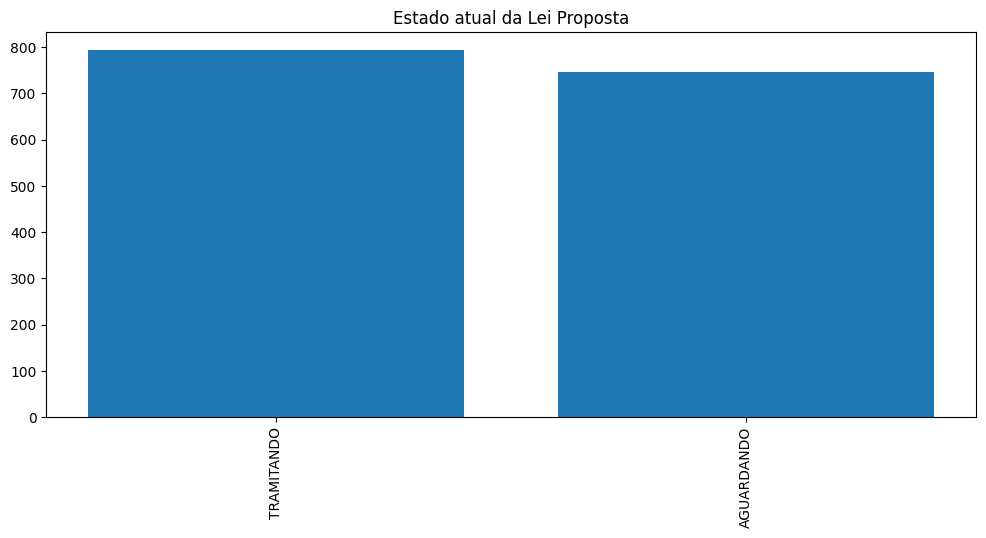

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["situacao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Estado atual da Lei Proposta")
plt.show()

In [13]:
sexo = df['sexo'].value_counts().reset_index()

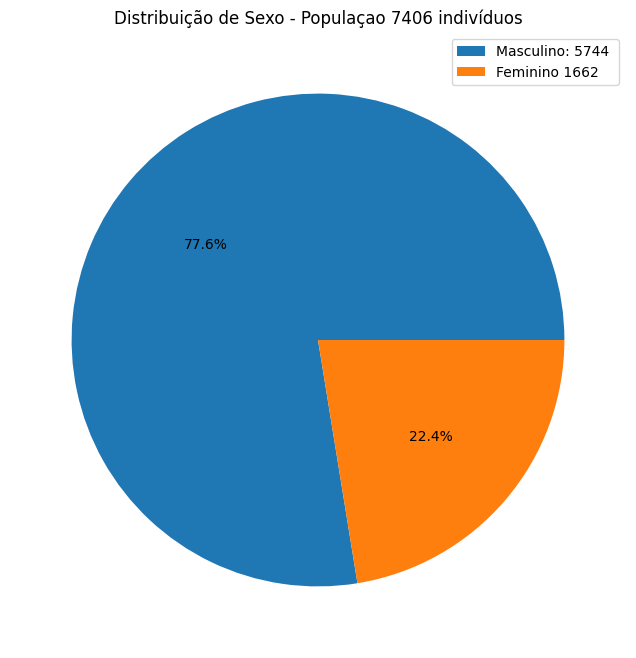

In [14]:
fg, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.pie(sexo["count"], autopct="%.1f%%")
ax.set_title(
    f"Distribuição de Sexo - Populaçao {df['sexo'].count()} indivíduos")
ax.legend([f"Masculino: {sexo['count'][0]} ", f"Feminino {sexo['count'][1]}"])
plt.show()

In [15]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

In [16]:
df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA") ] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_16260\1879082908.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (
C:\Users\alexa\AppData\Local\Temp\ipykernel_16260\1879082908.py:1: SettingWithCopyWar

In [17]:
cor = df["cor"].value_counts().reset_index()

In [18]:
cor["cor"].unique()
cor

,cor,count
0,BRANCA,2212
1,OUTROS,1166


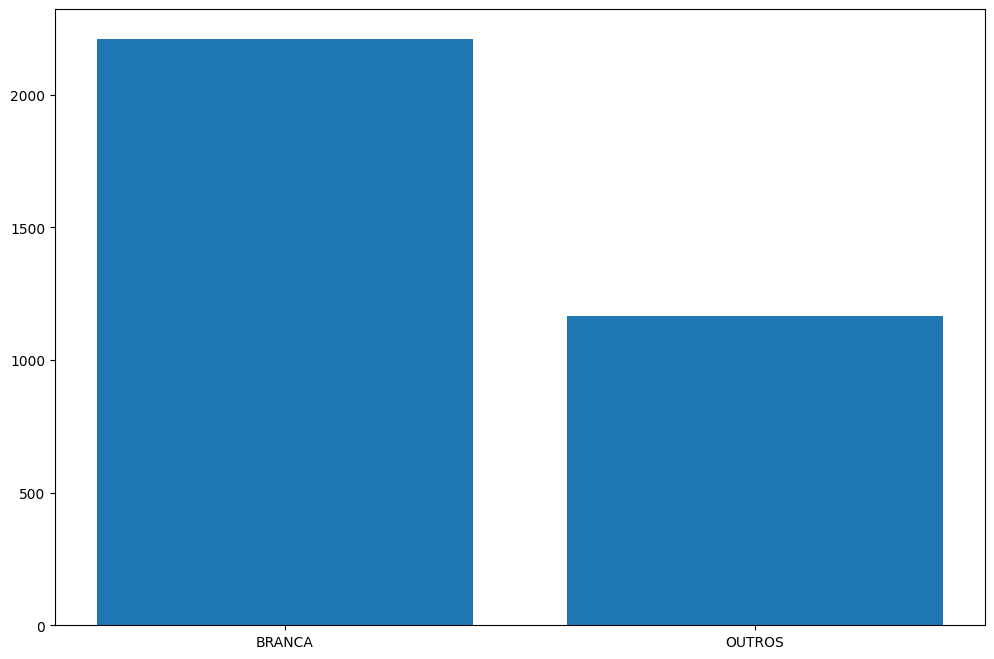

In [19]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [20]:
df.iloc[10:50]

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
10,Dispõe sobre a reintegração no emprego dos fun...,"Garantia, reintegração, retorno, emprego, ex-f...",FERNANDO MONTEIRO DE ALBUQUERQUE,M,1976-09-17,Recife - PE,Superior,NaN,NaN,NaN,BRANCA
11,"Altera as Leis nºs 8.429, de 2 de junho de 19...","Alteração, Lei da Improbidade Administrativa, ...",KIM PATROCA KATAGUIRI,M,1996-01-28,Salto - SP,Superior Incompleto,NaN,NaN,NaN,OUTROS
12,Autoriza o Poder Executivo a criar o Programa ...,"Autorização, Executivo, criação, Programa de I...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,NaN,NaN,BRANCA
13,"Altera a Lei nº 9.656, de 3 de junho de 1998, ...","Alteração, Lei dos Planos de Saúde, cobertura,...",HILDELIS SILVA DUARTE JUNIOR,M,1986-09-15,Rio de Janeiro - RJ,Doutorado Incompleto,NaN,NaN,NaN,BRANCA
14,Dispõe sobre o Estatuto do Nascituro e dá outr...,"Criação, Estatuto do Nascituro, proteção, nasc...",PRISCILA BEZERRA DA COSTA,F,1984-09-12,Fortaleza - CE,Superior,NaN,NaN,NaN,OUTROS
15,"Altera a Lei nº 5.991, de 17 de setembro de 19...","Alteração, Lei de Controle Sanitário de Medica...",ALESSANDRA HABER CARVALHO SANTOS,F,1988-09-15,Belém - PA,Superior,NaN,NaN,NaN,BRANCA
16,Dá nova redação ao § 4º do art. 201 da Constit...,"Previdência Social, vinculação, reajuste, valo...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,NaN,NaN,BRANCA
17,"Revoga a Lei Complementar nº 110, de 29 de jun...","Revogação, Lei de Atualização Monetária do FG...",RODRIGO SANTANA VALADARES,M,1989-08-06,Aracaju - SE,Superior,NaN,NaN,NaN,BRANCA
18,"Dispõe sobre a prática de tatuagem e ""piercing"".","Funcionamento, estabelecimento comercial, prof...",LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,M,1977-12-10,Rio de Janeiro - RJ,Superior,NaN,NaN,NaN,OUTROS
19,Dispõe sobre a obrigatoriedade de banheiros pú...,"Obrigatoriedade, agência bancária, instalação,...",DANIELA MOTE DE SOUZA CARNEIRO,F,1976-02-10,Rio de Janeiro - RJ,Pós-Graduação,NaN,NaN,NaN,BRANCA


In [21]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

In [22]:
df = df.dropna(subset=["ementa"])

## TF - IDF


In [23]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()

In [24]:
vocab

array(['00', '000', '0001', ..., 'única', 'único', 'útero'], dtype=object)

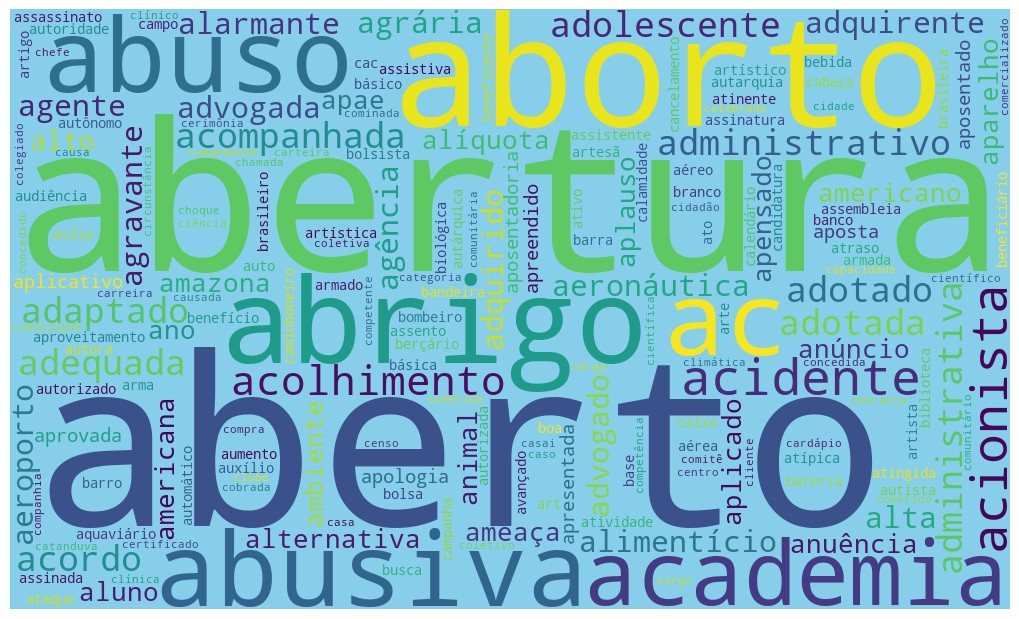

In [25]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [26]:
X

<3250x8509 sparse matrix of type '<class 'numpy.float64'>'
	with 54421 stored elements in Compressed Sparse Row format>

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])

In [28]:
y = df["cor"]

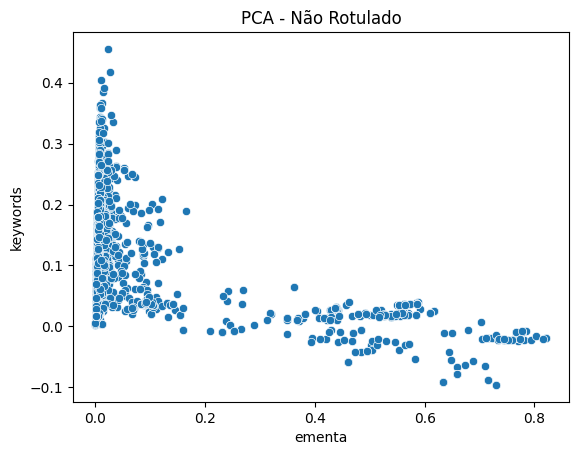

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=3)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'keywords', 'cor',])


# Visualize the transformed data

sns.scatterplot(x='ementa', y="keywords", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

In [30]:
df["cor"]

0       0
1       1
2       0
3       0
4       0
       ..
3373    1
3374    0
3375    0
3376    1
3377    1
Name: cor, Length: 3250, dtype: int32

In [31]:
df_pca["cor"]

0       0.002732
1       0.006011
2       0.020670
3       0.009780
4       0.009228
          ...   
3245    0.000693
3246    0.007921
3247    0.003970
3248   -0.104130
3249    0.167579
Name: cor, Length: 3250, dtype: float64

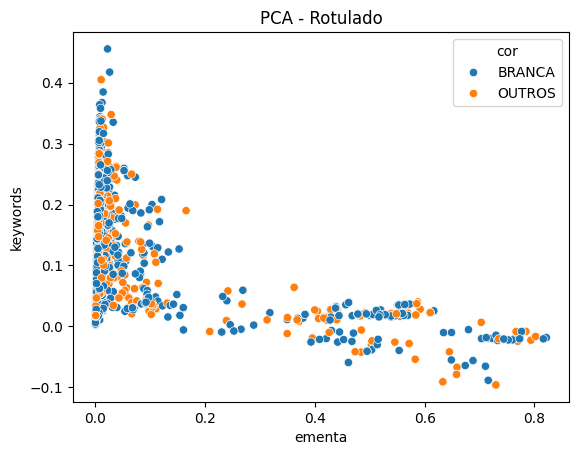

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=3)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'keywords', 'cor',])

y_map = {0: 'BRANCA', 1: "OUTROS"}


df_pca["cor"] = df["cor"].map(y_map)

# Visualize the transformed data

sns.scatterplot(x='ementa', y="keywords", hue="cor", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [33]:
df["cor"].value_counts()

cor
0    2134
1    1116
Name: count, dtype: int64

In [34]:
df["cor"].unique()

array([0, 1])

In [35]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [36]:
X_train

<2600x8509 sparse matrix of type '<class 'numpy.float64'>'
	with 43811 stored elements in Compressed Sparse Row format>

In [37]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [38]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=1, tol=0.0001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.std())

Cross-Validation Results: [0.60317059 0.55284261 0.64123635 0.58250649 0.61448808]
Mean F1 Score: 0.029811441937854517


In [39]:
# Fazer Acuracia do cross validation

Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.71      0.97      0.82       423
           1       0.84      0.25      0.39       227

    accuracy                           0.72       650
   macro avg       0.77      0.61      0.60       650
weighted avg       0.75      0.72      0.67       650



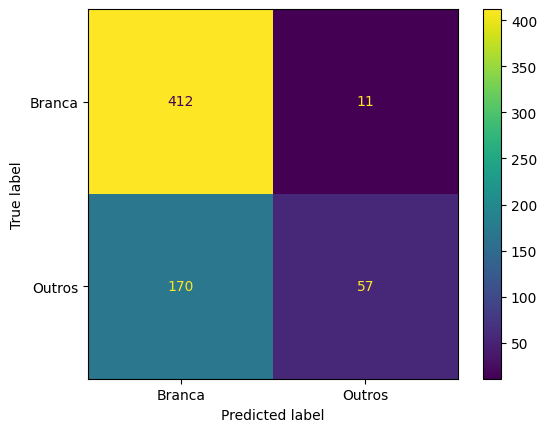

In [40]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

In [41]:
y_train

794     0
670     1
3133    0
1835    0
1188    0
       ..
1095    0
1130    0
1294    0
860     0
3298    1
Name: cor, Length: 2600, dtype: int32

# SGD Classifier


In [42]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.69384615 0.68       0.70615385 0.68461538 0.71846154]
Mean F1 Score: 0.6966153846153846


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       423
           1       0.57      0.51      0.54       227

    accuracy                           0.70       650
   macro avg       0.66      0.65      0.66       650
weighted avg       0.69      0.70      0.69       650



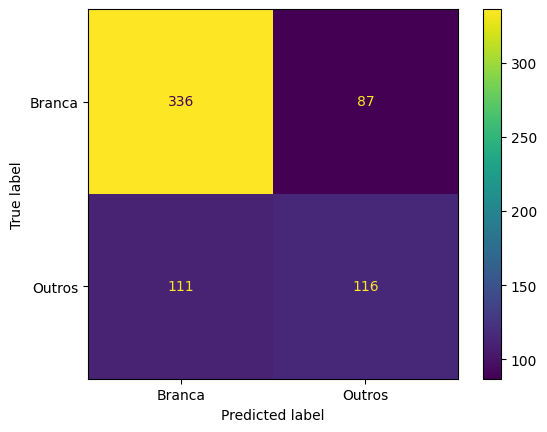

In [43]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [44]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=1, weights="uniform", algorithm="brute", leaf_size=30, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.67692308 0.64       0.69538462 0.67846154 0.70615385]
Mean F1 Score: 0.6793846153846154


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       423
           1       0.54      0.54      0.54       227

    accuracy                           0.68       650
   macro avg       0.65      0.65      0.65       650
weighted avg       0.68      0.68      0.68       650



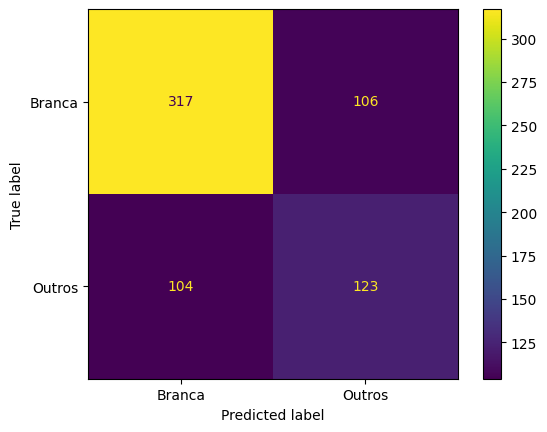

In [45]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [46]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.000001, C=10, multi_class='ovr', dual=True)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.69384615 0.66461538 0.70307692 0.67846154 0.71692308]
Mean F1 Score: 0.6913846153846154


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       423
           1       0.56      0.54      0.55       227

    accuracy                           0.69       650
   macro avg       0.66      0.66      0.66       650
weighted avg       0.69      0.69      0.69       650



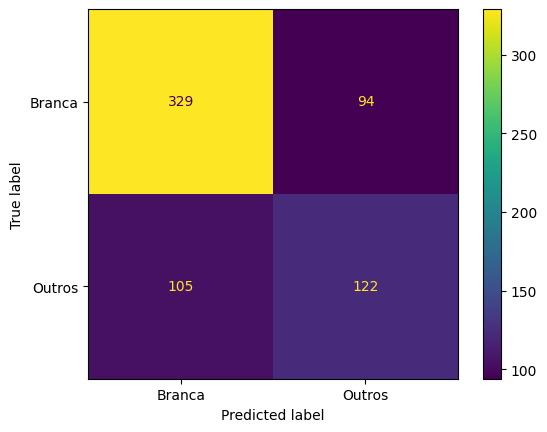

In [47]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [48]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.73      0.90      0.80       423
           1       0.66      0.38      0.49       227

    accuracy                           0.72       650
   macro avg       0.70      0.64      0.65       650
weighted avg       0.71      0.72      0.69       650



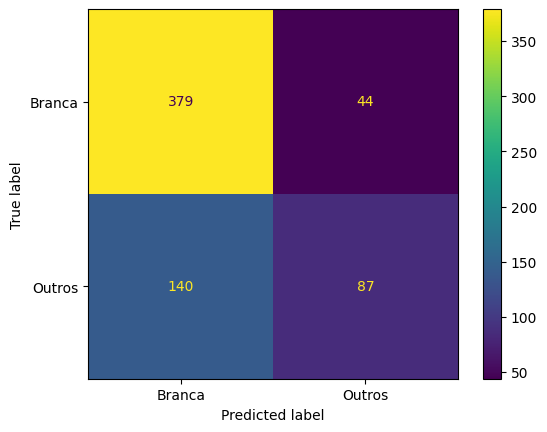

In [ ]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

In [ ]:
model.feature_importances_

array([5.69042019e-05, 8.71349680e-05, 0.00000000e+00, ...,
       2.85894166e-06, 3.61034944e-04, 6.35300127e-06])

# Decision Tree


Cross-Validation Results: [0.69076923 0.67692308 0.72923077 0.69384615 0.72      ]
Mean F1 Score: 0.7021538461538462


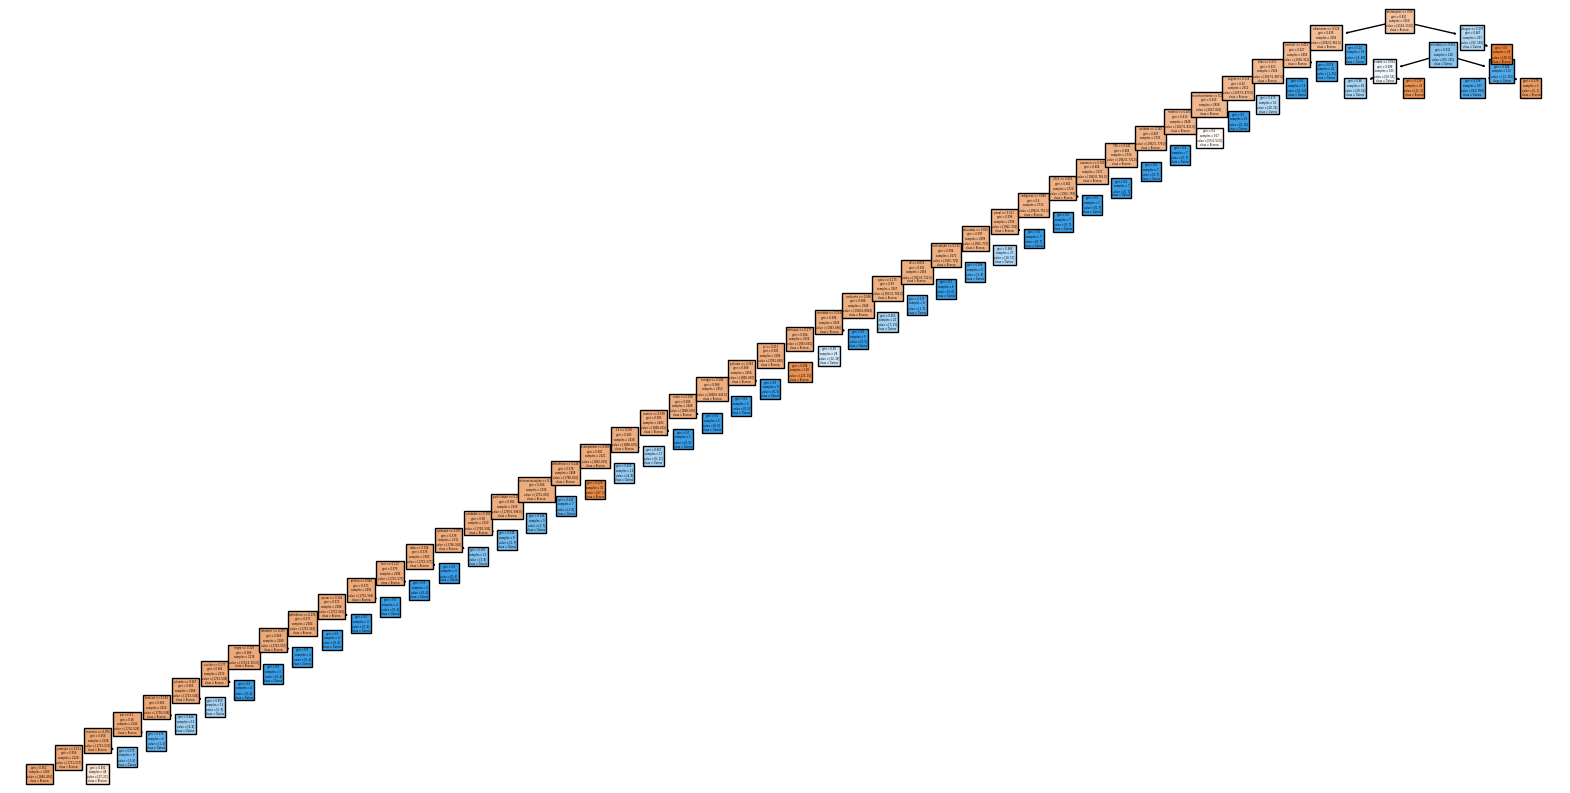

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
model.fit(X, y)
# Plot the decision tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(model,  feature_names=vocab.split(), class_names=["Branca", "Outros"], filled=True)

plt.show()


C:\Users\alexa\AppData\Local\Temp\ipykernel_20840\1547537519.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10_words[word + "_Frequency"] = df_top_10_words['ementa'].str.count(word)
C:\Users\alexa\AppData\Local\Temp\ipykernel_20840\1547537519.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10_words[word + "_Frequency"] = df_top_10_words['ementa'].str.count(word)
C:\Users\alexa\AppData\Local\Temp\ipykernel_20840\1547537519.py:17: SettingWithCopyWarning: 
A value is trying to be set o

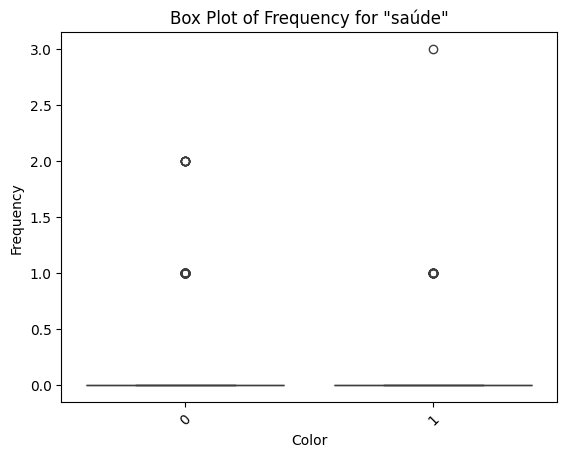

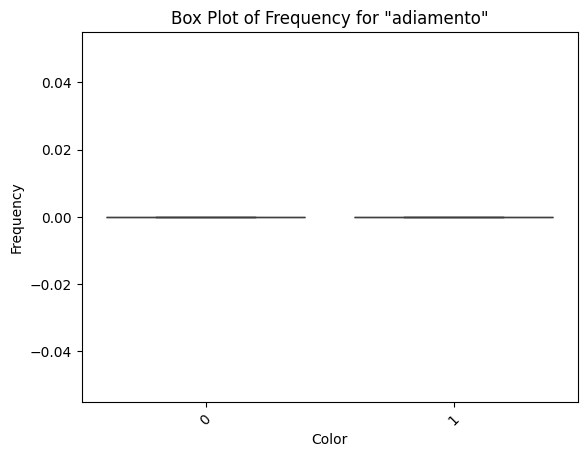

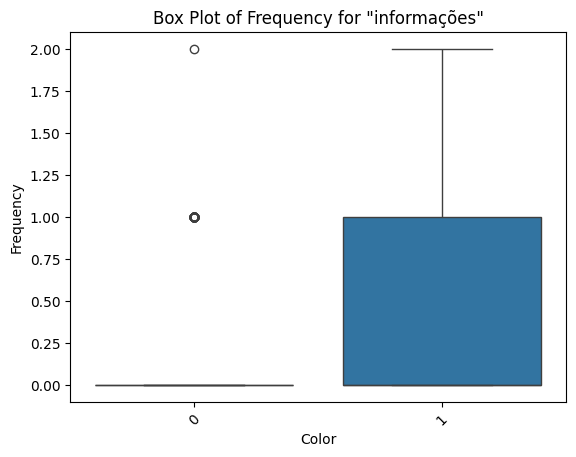

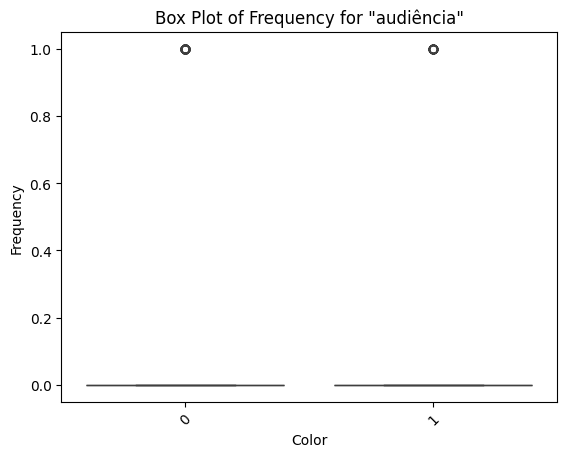

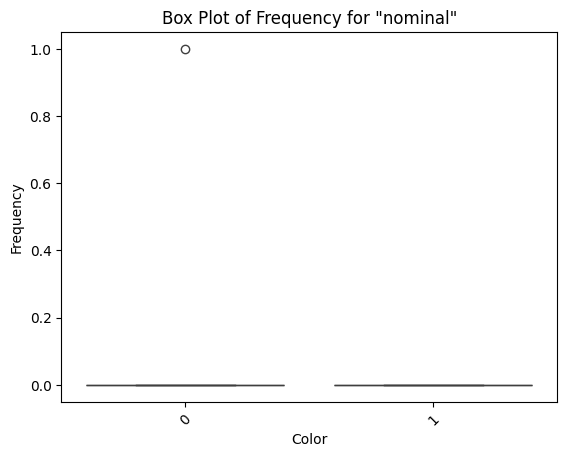

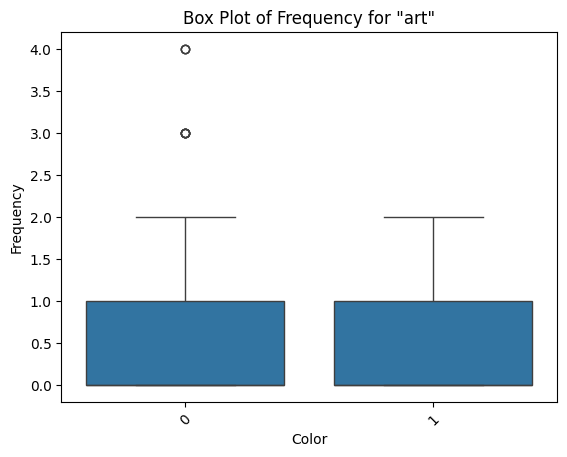

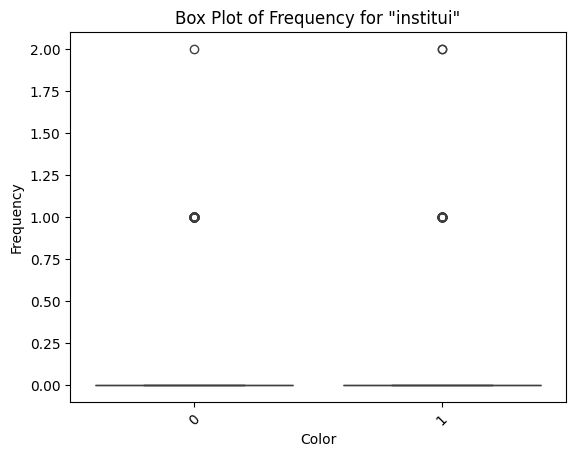

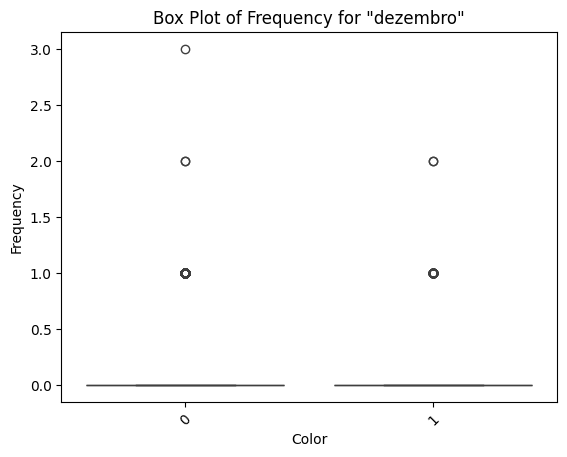

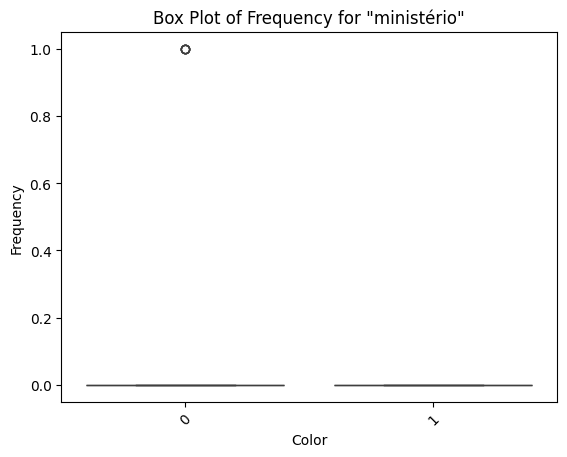

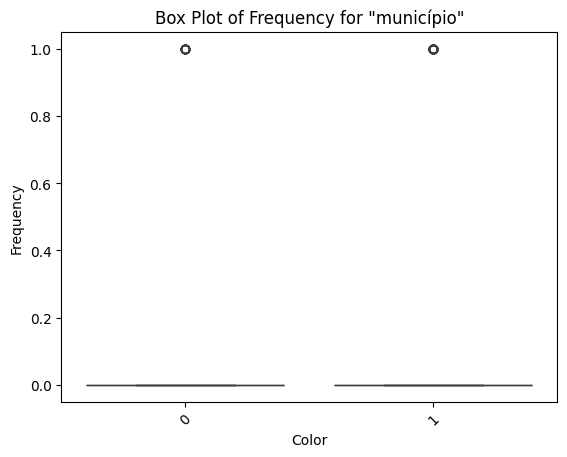

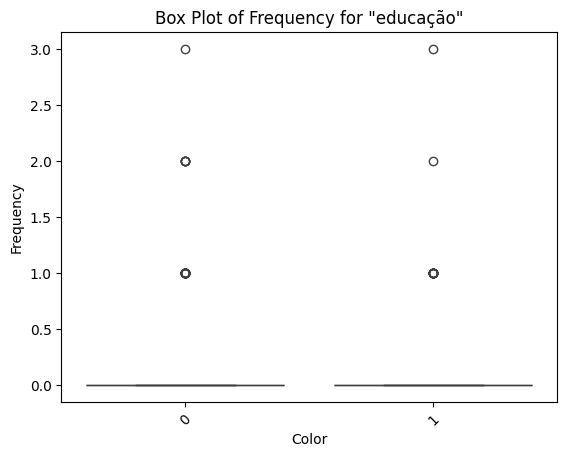

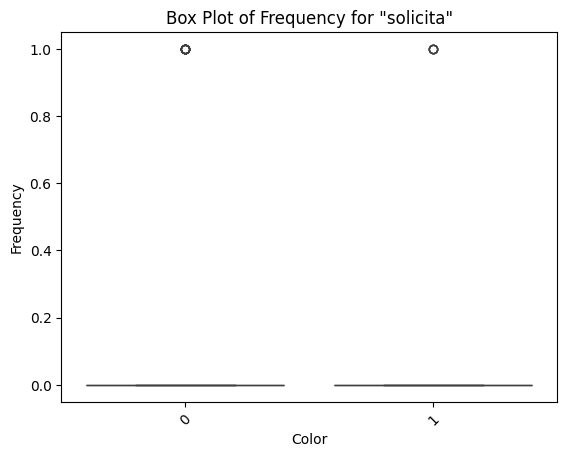

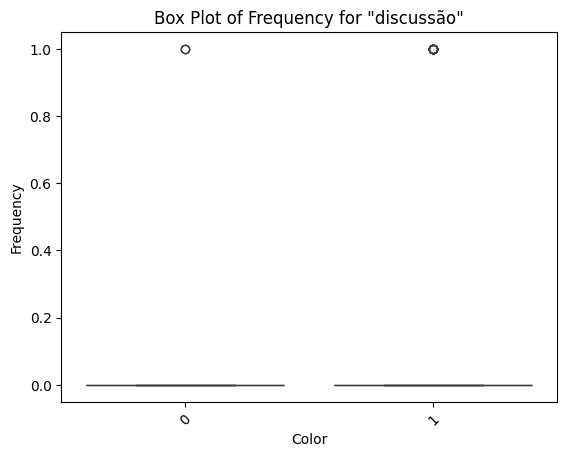

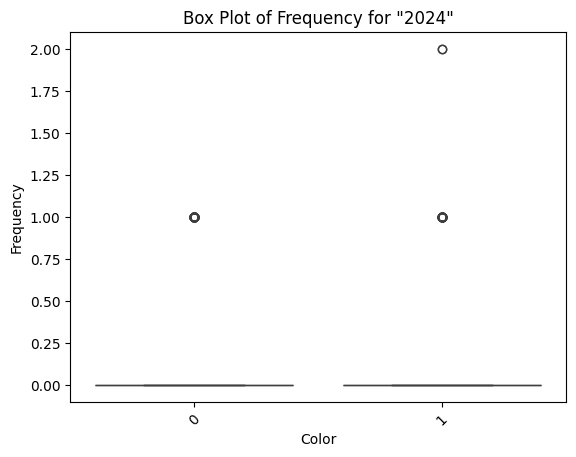

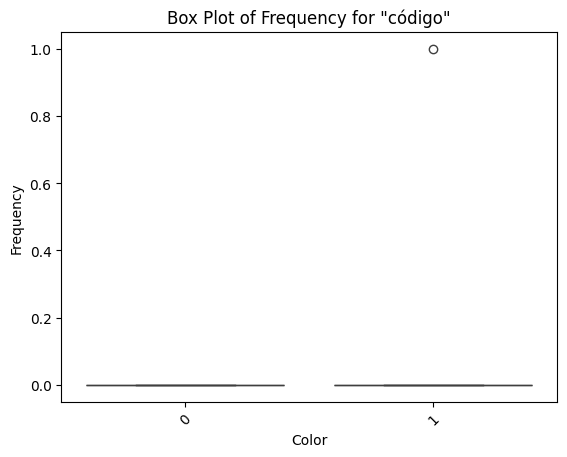

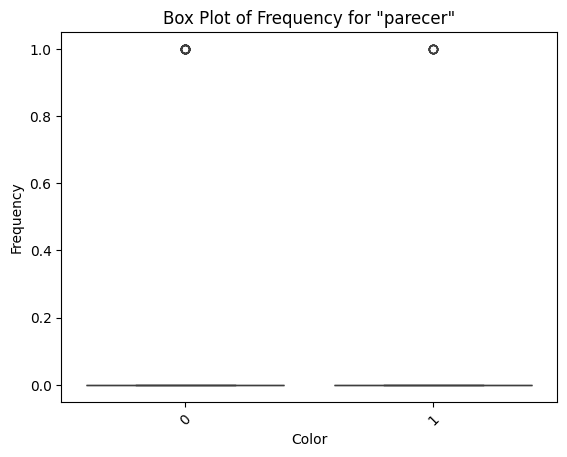

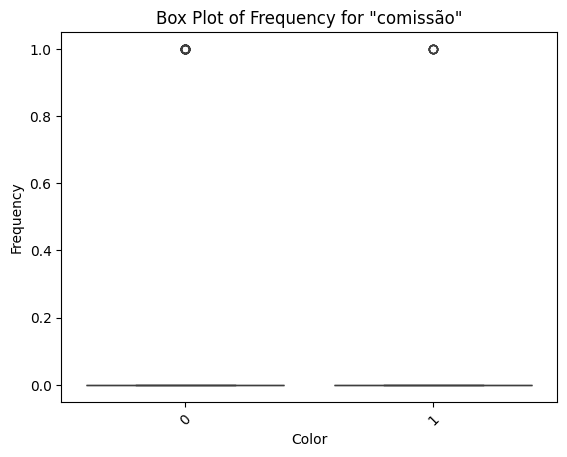

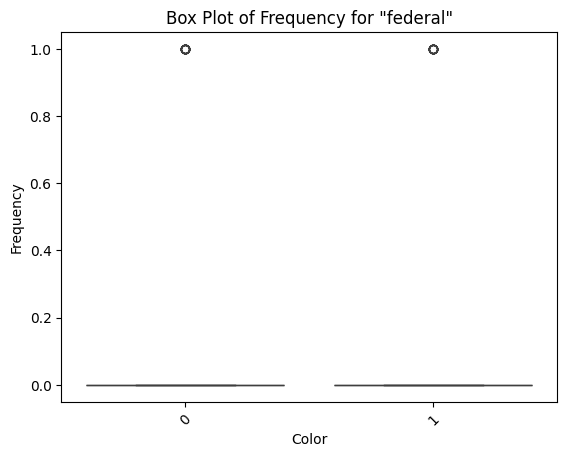

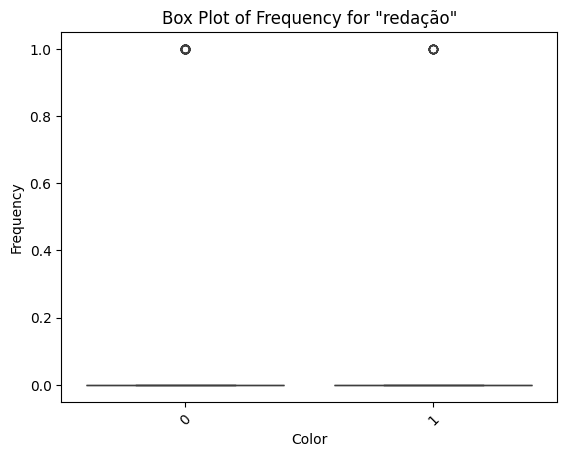

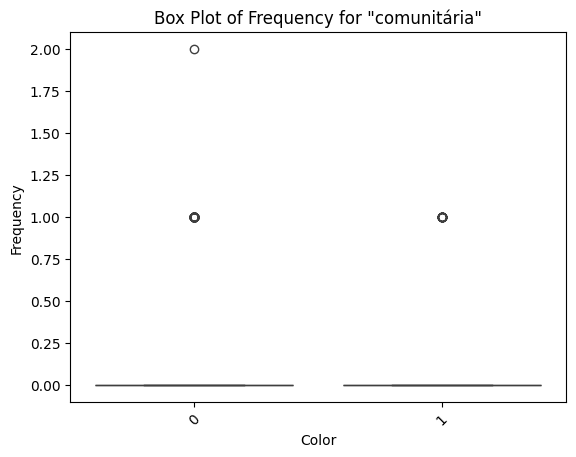

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# feature_names = tf_idf.get_feature_names_out()


# word_frequencies = X_train.sum(axis=0).A1
# df_frequencies = pd.DataFrame({"Word": feature_names, "Frequency": word_frequencies})

# top_10_words = df_frequencies.nlargest(100, 'Frequency')
# top_10_words = top_10_words.iloc[20:40]
# df_top_10_words = df[df['ementa'].str.contains('|'.join(top_10_words['Word'].tolist()))]

# for word in top_10_words['Word']:
#     df_top_10_words[word + "_Frequency"] = df_top_10_words['ementa'].str.count(word)


# for word in top_10_words['Word']:
#     # Filtrar o DataFrame para incluir apenas as colunas relevantes
#     df_word = df_top_10_words[['cor', word + "_Frequency"]]
    
#     # Plotar o boxplot
#     sns.boxplot(data=df_word, x='cor', y=word + "_Frequency")
#     plt.title(f'Box Plot of Frequency for "{word}"')
#     plt.xlabel('Color')
#     plt.ylabel('Frequency')
#     plt.xticks(rotation=45)  
#     plt.show()